# Milestone 4: Baseline Model, Pipeline Development, and TF Meeting

<b>Project Group 2:</b> <i> Max Bahar, Mila Ivanovska, Stefan Chu, Ted McCulloch</i>


#### Effective Notebook Submission Guidelines:

[] Start with a clear, concise problem statement.

[] Organize logically with headings and subheadings; table of contents are required!

[] Explain code, choices, and results using comments and markdown.

[] Use clear, well-labeled visualizations with descriptive captions.

[] Maintain clean, readable code with structured processes.

[] Ensure reproducibility: the notebook should run error-free and document data sources. No errors. No warning messages.


## Notes from Pavlos OH

Use **Mixture of Experts**! Use a meta model to aggregate the predictions from the first model and predict the class using a second model. 

We have $N$ states that consist of multiple states from $M$ objects.

We create a first model that predicts all $N$ states.

For each object, we choose $K$ observation/state predictions (will need to be padded/truncated for objects with less/more than $K$ observation/state predictions). 

Then, we create a second model that aggregates the $K$ observations for each of the $M$ objects to generate a class prediction for each object.

Graphically, for $x_t^{(i)}$, the state in time $t$ for observation $i$:
$$
    x^{(i)}_t \rightarrow \text{MODEL 1} \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{META MODEL} \rightarrow \hat{y}
$$

We must be very careful about creating validation sets, making sure that these are defined correctly.

Pavlos mentioned that the meta model could be a RNN, specifying a max length for the specific fold/window of predictions/data to use by the meta model.

Meta model could also utilize gates to learn which specific inputs they should prioritize.

Keywords to look for: ,ixture models, stacking models, blending models.

If Pavlos were designing it, the architecture would look like:
$$
    x_t^{(i)} \rightarrow \text{NN}_1 \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{NN}_2 \rightarrow \hat{y}
$$
And the loss from NN_1 and NN_2 are combined somehow to train the model simultaneously.

In [ ]:
# imports
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# utilities
import utils.preprocessing as pp
import utils.visualization as viz
import utils.time as tu

## 1. Introduction and Problem Statement

Currently, there are around 30,000 publicly cataloged objects in Earth's orbit. In reality, the number is likely much higher, as 1) not every piece of debris in orbit has a known position or identification number,  2) not every payload is publicly disclosed by the government of origin, and  3) different organizations report varying figures.

Traditionally, space objects are classified into three categories:

1. **Payloads**: Functional spacecraft or satellites launched into space to perform specific missions, such as communication, navigation, or research. The total count in orbit is around 14,000, but the number still active or operational is estimated to be about 11,600.

2. **Rocket Bodies**: Parts of launch vehicles (e.g., stages) that delivered payloads to orbit but remain in space as non-operational objects.

3. **Debris**: Non-functional fragments or objects in space, including pieces from collisions, explosions, or decommissioned satellites, that no longer serve any purpose.

While all objects are subject to the same orbital perturbations, the nature of each object type should produce identifiable patterns in their orbital elements. For example, active payloads will conduct station-keeping maneuvers to maintain their desired orbits. Geostationary satellites, for instance, have orbital periods of nearly exactly 1,440 minutes—matching Earth's rotation. However, if they stop performing station-keeping maneuvers, their orbits will begin to drift due to various perturbative forces (gravity, drag, radiation pressure, solar activity, etc.). Likewise, although both are essentially space junk, debris and rocket bodies should also exhibit distinct orbital behaviors due to differences in their average size, mass, and origin.


### _Our question is:_



**Given a history of orbital states, can we predict with confidence the object's type?**

Initially, we aimed to use two years of orbital data, removing time-dependent elements and identifiers to train our model to perform type classification. However, we are now pivoting to leverage the time dimension, using not a stationary set of elements, but rather a time-separated element histories as input to our three-type classification model. This pivot allows us to utilize more complex modeleling classes and techniques. 

Our EDA has confirmed that there are differences in orbital elements amongst object types, which are most pronounced in inclination, eccentritiy, apogee, and argument of perigee. Moreover, by examing the correlations between our features, we identified several meaningful patterns (and noted the ones which were trivial/meaningless). 

## 2.  Comprehensive EDA Review


[] Summarize key findings from EDA, focusing on how these insights informed feature engineering and model selection.

[] Detail the feature engineering process, including transformations, encoding, or selection techniques, with justifications rooted in EDA.

[] Include visualizations that support analytical decisions, linking back to the problem statement and project goals.

In [ ]:
# Separate features into different categories
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] 
X_numerical_revised = X_numerical + ['MEAN_MOTION_1ST_DER', 'B_STAR']
response = 'TYPE'

# Fetch final dataframe
df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file

In [ ]:
# Separate data into separate dataframes for each clas
df_payload = df_final[df_final['TYPE'] == 'PAYLOAD']
df_rb = df_final[df_final['TYPE'] == 'ROCKET BODY']
df_debris = df_final[df_final['TYPE'] == 'DEBRIS']  

### Key Findings from EDA

**MAX COMMENT: We will probably need visualizations to support these key findings.**

1. Mean anomaly is correlated with the epoch time and therefore likely does not contain meaningful information. We have decided to exclude it from our set of predictors.

2. We identified three meaningful patterns in the correlation matrix: (a) circular orbits have higher inclinations than elliptical orbits, (b) lower Earth orbits are more likely to be more inclined than higher Earth orbits, (c) lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity). 

3. When comparing semi-major axis, inclination, and eccentricity, we observe apparent differences in patterns across object types—even when holding orbital regime constant.

### Pivot to Time-dependent Modeling

Since we are now interested in the time dimension of our data, it is important to examine how states are distributed across different objects in our dataset. If objects from a certain class have a more/less detailed state history, it could significantly impact the results of our model.

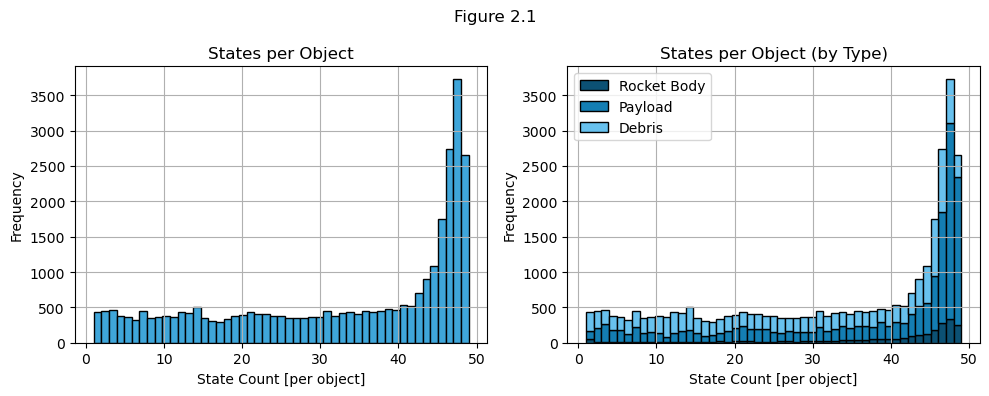

In [11]:
# Visualize number of states per object
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].hist(df_final['NUMBER'].value_counts().values, bins=49, edgecolor='black', color='#3FA6DA')
axs[0].set_title("States per Object")
axs[0].set_xlabel("State Count [per object]")
axs[0].set_ylabel("Frequency")
axs[0].grid(True)

axs[1].hist([df_rb['NUMBER'].value_counts().values,
             df_payload['NUMBER'].value_counts().values,
             df_debris['NUMBER'].value_counts().values], 
            bins=49, edgecolor='black', stacked=True, 
            color=["#0C5174", "#147EB3", "#68C1EE"], 
            label=['Rocket Body', 'Payload', 'Debris'])
axs[1].set_title("States per Object (by Type)")
axs[1].set_xlabel("State Count [per object]")
axs[1].set_ylabel("Frequency")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("Figure 2.1")
plt.tight_layout()
plt.show()


Figure 2.1 plots the number of states per object. We can observe that most states have around 40-50 objects, with all three classes following this general distribution. **MAX COMMENT: Add more about rocket body's distribution maybe?**

In [ ]:
# Group the states by the object, display time ranges for each object's states
df_epoch_min_max = df_final.groupby('NUMBER')['EPOCH'].agg(['min', 'max']).reset_index()
df_epoch_min_max['min_datetime'] = df_epoch_min_max['min'].apply(tu.year_doy_to_datetime)
df_epoch_min_max['max_datetime'] = df_epoch_min_max['max'].apply(tu.year_doy_to_datetime)
df_epoch_min_max 
# ########## MAX COMMENT ##########
# Should we show this dataframe? 
# I think the plots in Figure 2.2 do a great of showing the distribution of times.

,NUMBER,min,max,min_datetime,max_datetime
0,5,23074.130708,25074.298269,2023-03-15 03:08:13.188480,2025-03-15 07:09:30.415680
1,11,23074.509605,25074.189782,2023-03-15 12:13:49.911744,2025-03-15 04:33:17.176896
2,12,23074.278815,25074.143389,2023-03-15 06:41:29.609952,2025-03-15 03:26:28.815648
3,16,23074.443615,25074.636965,2023-03-15 10:38:48.364512,2025-03-15 15:17:13.811424
4,20,23074.333729,25074.195186,2023-03-15 08:00:34.178688,2025-03-15 04:41:04.034112
...,...,...,...,...,...
30490,63153,25074.513083,25074.513083,2025-03-15 12:18:50.365152,2025-03-15 12:18:50.365152
30491,63204,25074.412897,25074.412897,2025-03-15 09:54:34.267968,2025-03-15 09:54:34.267968
30492,63205,25074.038727,25074.038727,2025-03-15 00:55:45.999840,2025-03-15 00:55:45.999840
30493,63206,25074.006400,25074.006400,2025-03-15 00:09:12.999744,2025-03-15 00:09:12.999744


C:\Users\maxab\AppData\Local\Temp\ipykernel_36276\1690259482.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right");


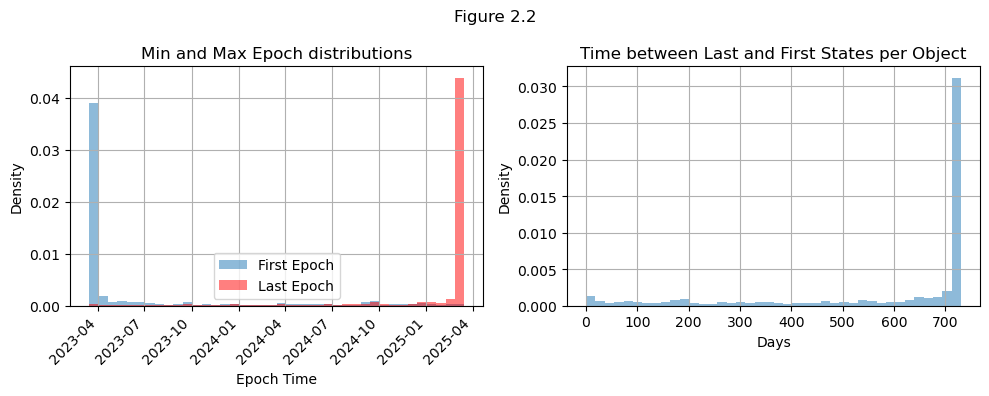

In [21]:
# Visualize distribution of earliest/latest state times and time ranges of states per object
num_bins = 40
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df_epoch_min_max['min_datetime'], bins=num_bins, alpha=0.5, label='First Epoch', density=True)
ax1.hist(df_epoch_min_max['max_datetime'], bins=num_bins, alpha=0.5, label='Last Epoch', density=True, color='red')

ax1.set_xlabel('Epoch Time')
ax1.set_ylabel('Density')
ax1.set_title('Min and Max Epoch distributions')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right");
ax1.grid(True)
ax1.legend()

ax2.hist((df_epoch_min_max['max_datetime'] - df_epoch_min_max['min_datetime']).dt.days,
         bins=b, alpha=0.5, density=True)

ax2.set_xlabel('Days')
ax2.set_ylabel('Density')
ax2.set_title('Time between Last and First States per Object')
ax2.grid(True)

plt.suptitle("Figure 2.2")
plt.tight_layout()
plt.show()


Figure 2.2 shows the distribution of the earliest and latest timestamp of the state histories of each object in our dataset. We can see that the first epoch for most of the objects in our dataset are on 2023-03-15, while most objects have a last epoch on 2025-03-15. This makes sense, since we collected our data by querying Space-Track's API every 15 days from 2023-03-15 to 2025-03-15. Consequently, most objects have a state history that span more than 700 days. We hope that this provides a sufficient amount of state information per object to make accurate class predictions for most objects. However, it is important to note that performance of the model can suffer for objects with shallow state histories.

## 3. Baseline Model Selection and Justification

[] Explain the choice of your baseline model, considering simplicity, interpretability, and relevance.

[] Detail the training process, including preprocessing, parameters, and metrics used for evaluation.

[] Present initial results, discussing alignment with expectations and project objectives.

In [7]:
def preprocess_data(df_to_use, X_numerical, response):
    label_encoder = LabelEncoder()
    scaler = StandardScaler()

    X = df_to_use[X_numerical]
    y = df_to_use[response]
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=0.2,
        random_state=101,
        stratify=y_encoded
    )

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return  X_train, X_test, y_train, y_test, label_encoder, scaler

In [8]:
X_train, X_test, y_train, y_test, label_encoder, scaler = preprocess_data(df_final, X_numerical, response)

In [9]:
# df_smote = pp.create_smote_df(df_final)
df_smote = pd.read_csv('../data/large/df_smote_v1.csv')  # <-- Run Part 2 of DataConsolidation.ipynb to produce file

## 4. Results Interpretation and Analysis

[] Analyze the baseline model’s performance, using appropriate metrics and visualizations.

[] Assess strengths and weaknesses of the model, proposing improvements for the next iteration.

## 5. Final Model Pipeline Setup

[] Outline steps for a pipeline for your final model, describing each component from data preprocessing to evaluation.

[] Document assumptions, parameter choices, and preliminary tuning considerations.


## Notes from Pavlos OH

Use **Mixture of Experts**! Use a meta model to aggregate the predictions from the first model and predict the class using a second model. 

We have $N$ states that consist of multiple states from $M$ objects.

We create a first model that predicts all $N$ states.

For each object, we choose $K$ observation/state predictions (will need to be padded/truncated for objects with less/more than $K$ observation/state predictions). 

Then, we create a second model that aggregates the $K$ observations for each of the $M$ objects to generate a class prediction for each object.

Graphically, for $x_t^{(i)}$, the state in time $t$ for observation $i$:
$$
    x^{(i)}_t \rightarrow \text{MODEL 1} \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{META MODEL} \rightarrow \hat{y}
$$

We must be very careful about creating validation sets, making sure that these are defined correctly.

Pavlos mentioned that the meta model could be a RNN, specifying a max length for the specific fold/window of predictions/data to use by the meta model.

Meta model could also utilize gates to learn which specific inputs they should prioritize.

Keywords to look for: ,ixture models, stacking models, blending models.

If Pavlos were designing it, the architecture would look like:
$$
    x_t^{(i)} \rightarrow \text{NN}_1 \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{NN}_2 \rightarrow \hat{y}
$$
And the loss from NN_1 and NN_2 are combined somehow to train the model simultaneously.

### Usage of ChatGPT

1. used it to help manipulate dataframe values relative to 'NUMBER' grouping
